# ICP Localization

Our goal is to find where the car is on a pre-built map by matching each LiDAR scan to the map using ICP.
The position error must stay below **1.2 meters** and the car must travel at least **170 meters**.

In [ ]:
import open3d as o3d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import os

DATA_DIR = "dataset"
FRAMES_DIR = os.path.join(DATA_DIR, "frames")

## Parameters

| Parameter | Value | Meaning |
|---|---|---|
| `MAP_VOXEL` | 0.2 m | Voxel size for downsampling the map -> smaller = more detail but slower |
| `SCAN_VOXEL` | 0.1 m | Voxel size for downsampling each LiDAR scan |
| `MAX_ITER` | 50 | Maximum ICP iterations per frame |
| `TOLERANCE` | 0.0001 m | Stop early if improvement is smaller than this |
| `MAX_CORR_DIST` | 1.0 m | Reject point matches further apart than 1.0 m |
| `SCAN_MAX_RANGE` | 30 m | Ignore LiDAR points beyond 30 m (sinc they tend to be noisy) |
| `LOCAL_MAP_RADIUS` | 80 m | Only use the part of the map within 80 m of the car |

In [3]:
MAP_VOXEL = 0.2
SCAN_VOXEL = 0.1
MAX_ITER = 50
TOLERANCE = 0.0001
MAX_CORR_DIST = 1.0
SCAN_MAX_RANGE = 30.0    
LOCAL_MAP_RADIUS = 80.0

In [4]:
def make_transform(R, t):
    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def apply_transform(points, T):
    R = T[:3, :3]
    t = T[:3, 3]
    return (R @ points.T).T + t

def rotation_matrix(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx

def pose_to_transform(x, y, z, roll, pitch, yaw):
    R = rotation_matrix(roll, pitch, yaw)
    t = np.array([x, y, z])
    return make_transform(R, t)

def filter_by_range(points, max_range):
    dists = np.linalg.norm(points, axis=1)
    return points[dists <= max_range]

def crop_local_map(map_points, center, radius):
    diffs = map_points - center
    dists = np.linalg.norm(diffs, axis=1)
    return map_points[dists <= radius]

In [5]:
# Load and downsample map
map_pcd = o3d.io.read_point_cloud(os.path.join(DATA_DIR, "map.pcd"))
map_pcd = map_pcd.voxel_down_sample(MAP_VOXEL)
map_points = np.asarray(map_pcd.points)
print(f"Map points after downsampling: {len(map_points)}")

# Load ground truth
gt = pd.read_csv(os.path.join(DATA_DIR, "ground_truth.csv"), skipinitialspace=True)
gt.columns = gt.columns.str.strip()
gt = gt.apply(pd.to_numeric, errors='coerce').fillna(0)
print(f"Ground truth frames: {len(gt)}")
print(gt.head())

Map points after downsampling: 122482
Ground truth frames: 1014
   Frame    x    y         z  roll  pitch  yaw
0      0  0.0  0.0  0.000000   0.0    0.0  0.0
1      1  0.0  0.0  0.015636   0.0    0.0  0.0
2      2  0.0  0.0  0.005846   0.0    0.0  0.0
3      3  0.0  0.0  0.005628   0.0    0.0  0.0
4      4  0.0  0.0  0.005628   0.0    0.0  0.0


## ICP Algorithm

ICP finds the best rotation and translation to align two point clouds.

**One iteration works like this:**

1. for each point in the scan, we find the closest point in the map using a KD-tree. Pairs with distance > 1.0 m are rejected as outliers.
2. We compute the centroids -> find the center (mean) of both matched point sets.
3. Then subtract each centroid so both sets are centered at the origin.
4. Build the Cross-covariance matrix with `S = P.T @ Q` -> captures how the two sets are related.
5. **SVD:** we decompose `S = U Σ Vt` to find the optimal rotation direction.
6. **Compute R and t:** rotation `R = V @ U.T`, translation `t = mean_Q − R @ mean_P`. A determinant check prevents a reflection instead of a rotation.
7. **Apply the transform:** We move the scan points using `R` and `t`.
8. **Compute error** -> mean distance between matched pairs after the transform.
9. Then we just repeat until the error change is smaller than the tolerance or our defined max iterations is reached.

In [6]:
def icp(source_pts, map_tree, map_points, max_iter=MAX_ITER, tolerance=TOLERANCE, max_corr_dist=MAX_CORR_DIST):
    src = source_pts.copy()
    cumulative_T = np.eye(4)
    prev_error = float('inf')

    for iteration in range(max_iter):
        # Step 1: Find correspondences
        matched_src = []
        matched_tgt = []

        for i in range(len(src)):
            [k, idx, dist_sq] = map_tree.search_knn_vector_3d(src[i], 1)
            if dist_sq[0] < max_corr_dist ** 2:
                matched_src.append(src[i])
                matched_tgt.append(map_points[idx[0]])

        if len(matched_src) < 10:
            break

        matched_src = np.array(matched_src)
        matched_tgt = np.array(matched_tgt)

        # Step 2: Compute centroids
        mu_P = np.mean(matched_src, axis=0)
        mu_Q = np.mean(matched_tgt, axis=0)

        # Step 3: Mean-center
        p_prime = matched_src - mu_P
        q_prime = matched_tgt - mu_Q

        # Step 4: Cross-covariance matrix
        S = p_prime.T @ q_prime

        # Step 5: SVD
        U, Sigma, Vt = np.linalg.svd(S)

        # Step 6: Compute R and t
        V = Vt.T
        if np.linalg.det(V @ U.T) < 0:
            V[:, -1] *= -1
        R = V @ U.T
        t = mu_Q - R @ mu_P

        # Step 7: Apply transform
        T_iter = make_transform(R, t)
        src = apply_transform(src, T_iter)
        cumulative_T = T_iter @ cumulative_T

        # Step 8: Compute error
        error = np.mean(np.linalg.norm(matched_tgt - apply_transform(matched_src, T_iter), axis=1))

        # Step 9: Check convergence
        if abs(prev_error - error) < tolerance:
            break
        prev_error = error

    return cumulative_T, prev_error

In [ ]:
row0 = gt.iloc[0]
current_pose = pose_to_transform(row0['x'], row0['y'], row0['z'],
                                 row0['roll'], row0['pitch'], row0['yaw'])
prev_pose = current_pose.copy()

num_frames = len(gt)
estimated_positions = []
gt_positions = []
lateral_errors = []
times = []

for i in range(num_frames):
    t_start = time.time()

    # Load and downsample scan
    frame_path = os.path.join(FRAMES_DIR, f"frame_{i}.pcd")
    if not os.path.exists(frame_path):
        continue

    scan_pcd = o3d.io.read_point_cloud(frame_path)
    scan_pcd = scan_pcd.voxel_down_sample(SCAN_VOXEL)
    scan_pts = np.asarray(scan_pcd.points)

    # Filter out distant LiDAR points since they are noisy, could cause wrong matches
    scan_pts = filter_by_range(scan_pts, SCAN_MAX_RANGE)

    # Motion prediction: extrapolate pose using delta between last two frames
    if i > 0:
        delta = current_pose @ np.linalg.inv(prev_pose)   # motion from prev -> current
        initial_pose = delta @ current_pose                # predict next pose
    else:
        initial_pose = current_pose.copy()

    scan_in_map = apply_transform(scan_pts, initial_pose)

    current_position = initial_pose[:3, 3]
    local_map = crop_local_map(map_points, current_position, LOCAL_MAP_RADIUS)

    if len(local_map) < 50:
        local_map = map_points

    # Build KD-tree on local map
    local_pcd = o3d.geometry.PointCloud()
    local_pcd.points = o3d.utility.Vector3dVector(local_map)
    local_tree = o3d.geometry.KDTreeFlann(local_pcd)

    # Run ICP to find correction on top of predicted pose
    T_correction, error = icp(scan_in_map, local_tree, local_map)

    prev_pose = current_pose.copy()
    current_pose = T_correction @ initial_pose

    est_x = current_pose[0, 3]
    est_y = current_pose[1, 3]
    estimated_positions.append([est_x, est_y])

    # Ground truth position
    gt_x = gt.iloc[i]['x']
    gt_y = gt.iloc[i]['y']
    gt_positions.append([gt_x, gt_y])

    # Lateral error
    lat_err = np.sqrt((est_x - gt_x)**2 + (est_y - gt_y)**2)
    lateral_errors.append(lat_err)

    t_end = time.time()
    times.append(t_end - t_start)

    if i % 100 == 0:
        print(f"Frame {i}/{num_frames-1} | Lateral error: {lat_err:.4f}m | Time: {times[-1]:.3f}s | Matches local map: {len(local_map)} pts")

estimated_positions = np.array(estimated_positions)
gt_positions = np.array(gt_positions)
print(f"\nDone. Processed {len(lateral_errors)} frames.")

Frame 0/1013 | Lateral error: 0.1720m | Time: 0.546s | Matches local map: 58529 pts
Frame 100/1013 | Lateral error: 0.0608m | Time: 0.118s | Matches local map: 65757 pts
Frame 200/1013 | Lateral error: 0.0733m | Time: 0.219s | Matches local map: 77985 pts
Frame 300/1013 | Lateral error: 0.1007m | Time: 0.405s | Matches local map: 94121 pts
Frame 400/1013 | Lateral error: 0.2185m | Time: 0.129s | Matches local map: 104884 pts
Frame 500/1013 | Lateral error: 0.0149m | Time: 0.501s | Matches local map: 103791 pts
Frame 600/1013 | Lateral error: 0.3146m | Time: 0.164s | Matches local map: 94534 pts
Frame 700/1013 | Lateral error: 0.0547m | Time: 0.363s | Matches local map: 78852 pts
Frame 800/1013 | Lateral error: 0.1482m | Time: 0.187s | Matches local map: 65290 pts
Frame 900/1013 | Lateral error: 0.1813m | Time: 0.264s | Matches local map: 55878 pts
Frame 1000/1013 | Lateral error: 0.2801m | Time: 0.199s | Matches local map: 48895 pts

Done. Processed 1014 frames.


## Visualization

The plots below show the lateral error per frame and the estimated trajectory compared to the ground truth.

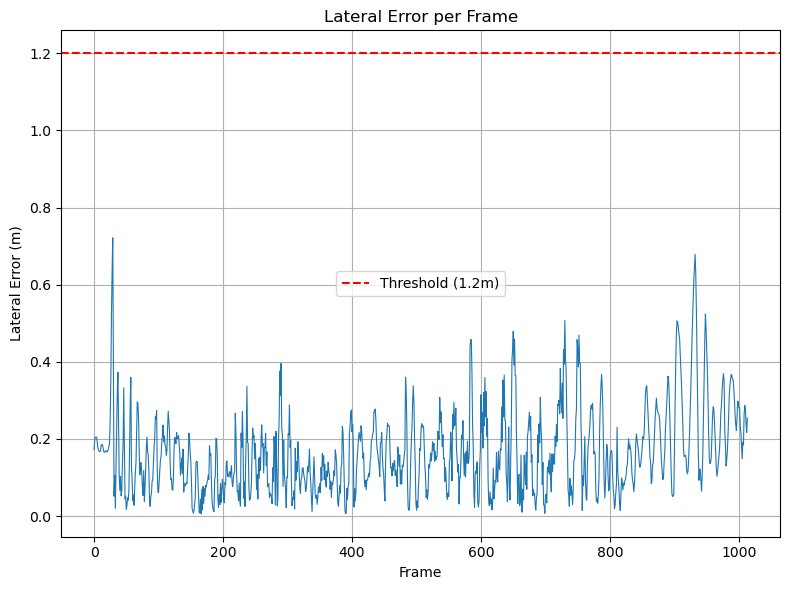

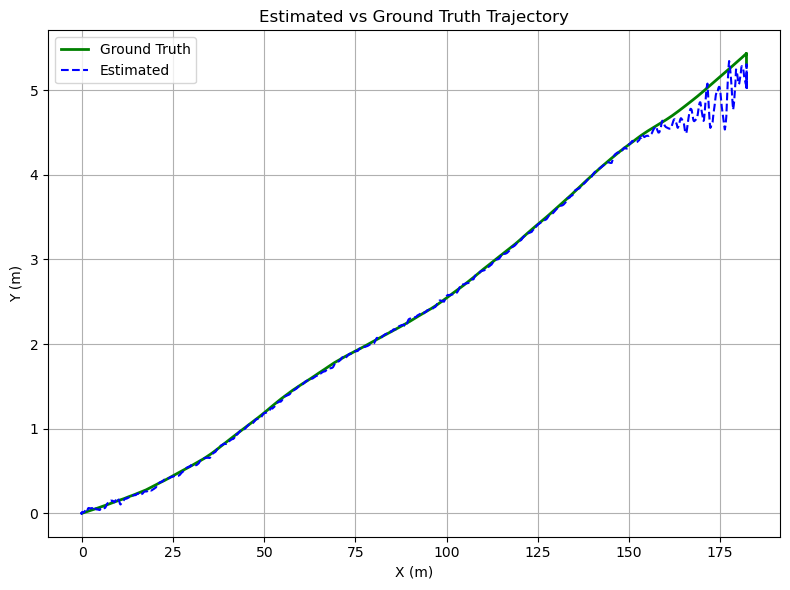

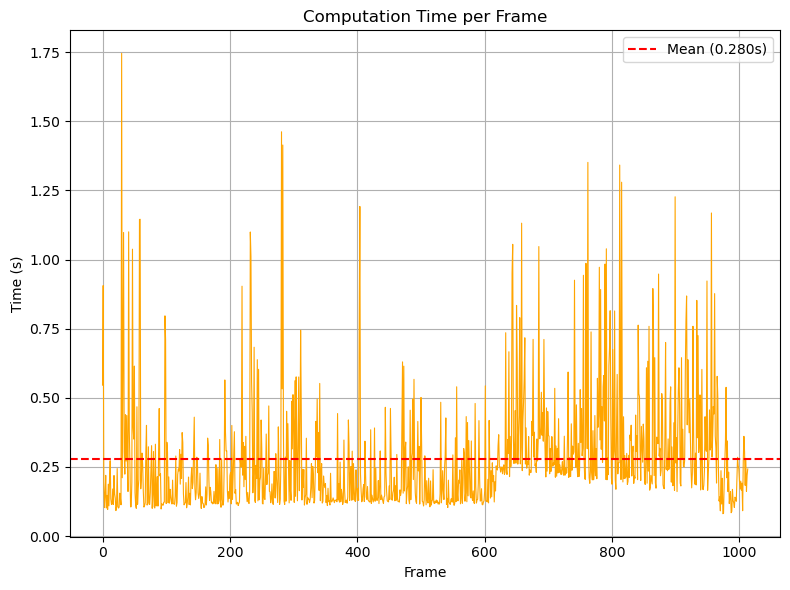

In [10]:
# Lateral error per frame
fig1, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(lateral_errors, linewidth=0.8)
ax1.axhline(y=1.2, color='r', linestyle='--', label='Threshold (1.2m)')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Lateral Error (m)')
ax1.set_title('Lateral Error per Frame')
ax1.legend()
ax1.grid(True)
plt.tight_layout()
plt.show()

# Estimated vs ground truth trajectory
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.plot(gt_positions[:, 0], gt_positions[:, 1], 'g-', label='Ground Truth', linewidth=2)
ax2.plot(estimated_positions[:, 0], estimated_positions[:, 1], 'b--', label='Estimated', linewidth=1.5)
ax2.set_xlabel('X (m)')
ax2.set_ylabel('Y (m)')
ax2.set_title('Estimated vs Ground Truth Trajectory')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# Computation time per frame
fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.plot(times, linewidth=0.8, color='orange')
ax3.axhline(y=np.mean(times), color='r', linestyle='--', label=f'Mean ({np.mean(times):.3f}s)')
ax3.set_xlabel('Frame')
ax3.set_ylabel('Time (s)')
ax3.set_title('Computation Time per Frame')
ax3.legend()
ax3.grid(True)
plt.tight_layout()
plt.show()

## Performance Metrics

Summary of the localization results across all 1014 frames.

In [ ]:
diffs = np.diff(estimated_positions, axis=0)
distances = np.sqrt(np.sum(diffs**2, axis=1))
total_distance = np.sum(distances)

print("=" * 50)
print("ICP LOCALIZATION RESULTS")
print("=" * 50)
print(f"Max lateral error:      {max(lateral_errors):.4f} m")
print(f"Mean lateral error:     {np.mean(lateral_errors):.4f} m")
print(f"Total distance:         {total_distance:.2f} m")
print(f"Mean time per frame:    {np.mean(times):.4f} s")
print(f"Frames processed:       {len(lateral_errors)}")
print("=" * 50)
print(f"Max error < 1.2m:       {'PASS' if max(lateral_errors) < 1.2 else 'FAIL'}")
print(f"Distance > 170m:        {'PASS' if total_distance > 170 else 'FAIL'}")

ICP LOCALIZATION RESULTS
Max lateral error:      0.7215 m
Mean lateral error:     0.1648 m
Total distance:         185.35 m
Mean time per frame:    0.2798 s
Frames processed:       1014
Max error < 1.2m:       PASS
Distance > 170m:        PASS
